In [1]:
# ═══════════════════════════════════════════════════════════════
# EmoWear — Cell 1: Dataset Structure Inspection
# Goal: Understand what's in the folder BEFORE writing any pipeline
# Rule: Read everything, assume nothing, report everything
# ═══════════════════════════════════════════════════════════════

from google.colab import drive
drive.mount('/content/drive')

import os
import pickle
import numpy as np

EMOWEAR_PATH = '/content/drive/MyDrive/R26_DS_012_RESEARCH_HDS/Datasets/EmoWear'

# ── STEP 1: What does the top-level folder look like? ──────────
print("=== TOP LEVEL CONTENTS ===")
top_items = sorted(os.listdir(EMOWEAR_PATH))
for item in top_items:
    full = os.path.join(EMOWEAR_PATH, item)
    kind = 'DIR' if os.path.isdir(full) else 'FILE'
    print(f"  [{kind}]  {item}")

# ── STEP 2: Look inside the first subject folder ──────────────
print("\n=== FIRST SUBJECT FOLDER CONTENTS ===")
# Take the first entry that looks like a subject folder
first_entry = top_items[0]
first_path  = os.path.join(EMOWEAR_PATH, first_entry)
if os.path.isdir(first_path):
    sub_items = sorted(os.listdir(first_path))
    for item in sub_items:
        full = os.path.join(first_path, item)
        size_kb = os.path.getsize(full) / 1024 if os.path.isfile(full) else 0
        print(f"  {item:<40}  {size_kb:>8.1f} KB")
else:
    print(f"  {first_entry} is a FILE, not a directory — dataset may be flat-structured")
    print(f"  Extension: {os.path.splitext(first_entry)[1]}")

# ── STEP 3: Check if subject folders are named S1/S2... or differently ──
print("\n=== SUBJECT FOLDER NAMING ===")
dirs = [d for d in top_items if os.path.isdir(os.path.join(EMOWEAR_PATH, d))]
files = [f for f in top_items if os.path.isfile(os.path.join(EMOWEAR_PATH, f))]
print(f"  Total directories: {len(dirs)}")
print(f"  Total files at top level: {len(files)}")
print(f"  First 10 directories: {dirs[:10]}")
print(f"  Top-level files: {files[:10]}")

Mounted at /content/drive
=== TOP LEVEL CONTENTS ===
  [DIR]  01-9TZK
  [DIR]  02-9TZO
  [DIR]  03-9U4C
  [DIR]  04-9U66
  [DIR]  05-9U8B
  [DIR]  06-9UA7
  [DIR]  07-9UAD
  [DIR]  08-9UB2
  [DIR]  09-9UDP
  [DIR]  10-9UHM
  [DIR]  11-9UIZ
  [DIR]  12-9UN3
  [DIR]  13-9UOF
  [DIR]  14-9UP0
  [DIR]  15-9UR2
  [DIR]  16-9USC
  [DIR]  17-9UTL
  [DIR]  18-9UVM
  [DIR]  19-9UY7
  [DIR]  20-9V52
  [DIR]  21-9V5J
  [DIR]  22-9V5N
  [DIR]  23-9VIV
  [DIR]  24-9VL3
  [DIR]  25-9VNK
  [DIR]  26-9VTJ
  [DIR]  27-9VUW
  [DIR]  28-9VXK
  [DIR]  29-9VXR
  [DIR]  30-9VYD
  [DIR]  31-9VZJ
  [DIR]  32-9VZN
  [DIR]  33-9VZR
  [DIR]  34-9W1R
  [DIR]  36-9W4C
  [DIR]  37-9W4X
  [DIR]  38-9W6A
  [DIR]  39-9W6G
  [DIR]  40-9W74
  [DIR]  41-9W7K
  [DIR]  42-9W7R
  [DIR]  43-9W91
  [DIR]  44-9WAY
  [DIR]  45-9WBS
  [DIR]  46-9WCE
  [DIR]  47-9WCU
  [FILE]  meta.csv
  [FILE]  questionnaire.csv

=== FIRST SUBJECT FOLDER CONTENTS ===
  markers-phase2.csv                             5.9 KB
  markers-unique.csv   

In [2]:
# ═══════════════════════════════════════════════════════════════
# EmoWear — Cell 2: Read metadata, markers, and signal headers
# Goal: demographics, condition labels, CSV format, sampling rates
# ═══════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import os

EMOWEAR_PATH = '/content/drive/MyDrive/R26_DS_012_RESEARCH_HDS/Datasets/EmoWear'

# ── 1. meta.csv ───────────────────────────────────────────────
print("=== meta.csv (first 10 rows) ===")
meta = pd.read_csv(os.path.join(EMOWEAR_PATH, 'meta.csv'))
print(meta.head(10).to_string())
print(f"\nShape: {meta.shape}")
print(f"Columns: {list(meta.columns)}")

# ── 2. questionnaire.csv ──────────────────────────────────────
print("\n=== questionnaire.csv (first 10 rows) ===")
quest = pd.read_csv(os.path.join(EMOWEAR_PATH, 'questionnaire.csv'))
print(quest.head(10).to_string())
print(f"\nShape: {quest.shape}")
print(f"Columns: {list(quest.columns)}")

# ── 3. First subject: markers-phase2.csv ──────────────────────
first_subj = '01-9TZK'
subj_path  = os.path.join(EMOWEAR_PATH, first_subj)

print(f"\n=== markers-phase2.csv ({first_subj}) ===")
markers = pd.read_csv(os.path.join(subj_path, 'markers-phase2.csv'))
print(markers.to_string())
print(f"\nShape: {markers.shape}")
print(f"Columns: {list(markers.columns)}")

# ── 4. markers-unique.csv ─────────────────────────────────────
print(f"\n=== markers-unique.csv ({first_subj}) ===")
mu = pd.read_csv(os.path.join(subj_path, 'markers-unique.csv'))
print(mu.to_string())

# ── 5. params.csv ─────────────────────────────────────────────
print(f"\n=== params.csv ({first_subj}) ===")
params = pd.read_csv(os.path.join(subj_path, 'params.csv'))
print(params.to_string())

# ── 6. surveys.csv ────────────────────────────────────────────
print(f"\n=== surveys.csv ({first_subj}) ===")
surveys = pd.read_csv(os.path.join(subj_path, 'surveys.csv'))
print(surveys.to_string())

# ── 7. Signal file headers + first few rows ───────────────────
signal_files = [
    'signals-bh3-ecg.csv',
    'signals-bh3-br.csv',
    'signals-bh3-rr.csv',
    'signals-bh3-acc.csv',
    'signals-bh3-hr.csv',
    'signals-bh3-bb.csv',
    'signals-e4-skt.csv',
    'signals-e4-acc.csv',
    'signals-e4-bvp.csv',
    'signals-e4-ibi.csv',
]

for fname in signal_files:
    fpath = os.path.join(subj_path, fname)
    df = pd.read_csv(fpath, nrows=8)
    print(f"\n=== {fname} ===")
    print(f"Columns: {list(df.columns)}")
    print(df.to_string())

=== meta.csv (first 10 rows) ===
   Code    ID  Sequence Experiment Empatica E4 Zephyr BioHarness 3 Front STb Back STb Water STb                                  Notes
0     1  9TZK         0        VAD         NaN                 NaN       NaN      NaN       NaN                                    NaN
1     1  9TZK         1       vid7         NaN                 NaN   missing  missing       NaN                                    NaN
2     1  9TZK         2       vid4         NaN                 NaN   missing  missing       NaN                                    NaN
3     1  9TZK         3      vid40         NaN                 NaN   missing  missing       NaN                                    NaN
4     1  9TZK         4      vid17         NaN                 NaN   missing  missing       NaN                                    NaN
5     1  9TZK         5      vid23         NaN                 NaN   missing  missing       NaN                                    NaN
6     1  9TZK         

In [3]:
# ═══════════════════════════════════════════════════════════════
# EmoWear — Cell 3: Sampling rates, age table, baseline durations,
#                   RR quality check, BVP startup, bb.csv meaning
# ═══════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import os

EMOWEAR_PATH = '/content/drive/MyDrive/R26_DS_012_RESEARCH_HDS/Datasets/EmoWear'

# ── 1. Compute actual sampling rates from timestamp diffs ──────
first_subj = '01-9TZK'
subj_path  = os.path.join(EMOWEAR_PATH, first_subj)

signal_rate_files = {
    'bh3-ecg'  : 'signals-bh3-ecg.csv',
    'bh3-br'   : 'signals-bh3-br.csv',
    'bh3-acc'  : 'signals-bh3-acc.csv',
    'bh3-hr'   : 'signals-bh3-hr.csv',
    'e4-skt'   : 'signals-e4-skt.csv',
    'e4-acc'   : 'signals-e4-acc.csv',
    'e4-bvp'   : 'signals-e4-bvp.csv',
}

print("=== COMPUTED SAMPLING RATES ===")
for name, fname in signal_rate_files.items():
    df = pd.read_csv(os.path.join(subj_path, fname), nrows=200)
    diffs = np.diff(df['timestamp'].values)
    median_diff = np.median(diffs)
    approx_hz   = round(1.0 / median_diff, 2) if median_diff > 0 else 'IRREGULAR'
    print(f"  {name:<12}  median_diff={median_diff:.5f}s  approx_hz={approx_hz}")

# bh3-rr is irregular (beat-by-beat), check separately
rr = pd.read_csv(os.path.join(subj_path, 'signals-bh3-rr.csv'))
print(f"\n  bh3-rr: IRREGULAR (beat-by-beat). {len(rr)} total RR intervals")
print(f"  RR value range: {rr['value'].min():.0f} – {rr['value'].max():.0f} ms")
print(f"  RR values outside 300-2000ms: {((rr['value'] < 300) | (rr['value'] > 2000)).sum()}")

# bh3-bb: what is this?
bb = pd.read_csv(os.path.join(subj_path, 'signals-bh3-bb.csv'))
print(f"\n  bh3-bb: {len(bb)} rows, value range {bb['value'].min()} – {bb['value'].max()}")
print(f"  bh3-bb first 15 values: {bb['value'].values[:15].tolist()}")
print(f"  bh3-bb timestamp diffs (first 10): {np.diff(bb['timestamp'].values[:11]).round(3).tolist()}")

# ── 2. Full age + gender table from questionnaire ──────────────
print("\n=== FULL AGE TABLE (questionnaire.csv) ===")
quest = pd.read_csv(os.path.join(EMOWEAR_PATH, 'questionnaire.csv'))
print(f"{'Code':<6} {'ID':<8} {'Age':<6} {'Gender':<8} {'Medication':<50}")
print("-" * 85)
for _, row in quest.iterrows():
    med = str(row.get('Other drug/medication consumption', '')).strip()
    med = med if med != 'never' and med != 'nan' else ''
    flag = ' <-- EXCLUDE age' if pd.notna(row['Age']) and (row['Age'] < 18 or row['Age'] > 30) else ''
    print(f"{str(row['Code']):<6} {str(row['ID']):<8} {str(row['Age']):<6} {str(row['Gender']):<8} {med:<50}{flag}")

# ── 3. Check questionnaire codes vs folder numbers ─────────────
print("\n=== FOLDER NUMBERS vs QUESTIONNAIRE CODES ===")
folders = sorted(os.listdir(EMOWEAR_PATH))
folder_dirs = [f for f in folders if os.path.isdir(os.path.join(EMOWEAR_PATH, f))]
folder_nums = set(int(f.split('-')[0]) for f in folder_dirs)
quest_codes = set(quest['Code'].astype(int).values)
print(f"  Folder numbers present: {sorted(folder_nums)}")
print(f"  Questionnaire codes:    {sorted(quest_codes)}")
print(f"  In questionnaire but NO folder: {sorted(quest_codes - folder_nums)}")
print(f"  Folder but NOT in questionnaire: {sorted(folder_nums - quest_codes)}")

# ── 4. Baseline duration across ALL subjects ───────────────────
print("\n=== BASELINE DURATION ACROSS ALL SUBJECTS ===")
print(f"{'Folder':<15} {'baselineB':>10} {'baselineE':>10} {'duration(s)':>12} {'Note'}")
print("-" * 60)
for folder in sorted(folder_dirs):
    mu_path = os.path.join(EMOWEAR_PATH, folder, 'markers-unique.csv')
    try:
        mu = pd.read_csv(mu_path)
        bB = mu['baselineB'].values[0]
        bE = mu['baselineE'].values[0]
        dur = bE - bB
        note = 'OK' if dur >= 60 else 'SHORT < 60s'
        print(f"{folder:<15} {bB:>10.3f} {bE:>10.3f} {dur:>12.1f}   {note}")
    except Exception as e:
        print(f"{folder:<15} ERROR: {e}")

# ── 5. E4 BVP startup artifact check ─────────────────────────
print("\n=== E4 BVP STARTUP ARTIFACT (first 20 samples) ===")
bvp = pd.read_csv(os.path.join(subj_path, 'signals-e4-bvp.csv'), nrows=20)
print(bvp.to_string())

# ── 6. BH3 ECG startup check ─────────────────────────────────
print("\n=== BH3 ECG STARTUP (first 20 samples) ===")
ecg = pd.read_csv(os.path.join(subj_path, 'signals-bh3-ecg.csv'), nrows=20)
print(ecg.to_string())

# ── 7. When does the baseline window fall relative to signals? ─
print("\n=== BASELINE TIMING vs SIGNAL START (subject 01) ===")
mu01 = pd.read_csv(os.path.join(subj_path, 'markers-unique.csv'))
bB = mu01['baselineB'].values[0]
bE = mu01['baselineE'].values[0]
print(f"  Baseline: {bB:.3f}s to {bE:.3f}s  (duration={bE-bB:.1f}s)")

ecg_all = pd.read_csv(os.path.join(subj_path, 'signals-bh3-ecg.csv'))
rr_all  = pd.read_csv(os.path.join(subj_path, 'signals-bh3-rr.csv'))
skt_all = pd.read_csv(os.path.join(subj_path, 'signals-e4-skt.csv'))

ecg_bl = ecg_all[(ecg_all['timestamp'] >= bB) & (ecg_all['timestamp'] < bE)]
rr_bl  = rr_all[(rr_all['timestamp'] >= bB) & (rr_all['timestamp'] < bE)]
skt_bl = skt_all[(skt_all['timestamp'] >= bB) & (skt_all['timestamp'] < bE)]

print(f"  ECG samples in baseline: {len(ecg_bl)}")
print(f"  RR intervals in baseline: {len(rr_bl)}")
print(f"  RR values in baseline: {rr_bl['value'].values.tolist()}")
print(f"  SKT samples in baseline: {len(skt_bl)}")
print(f"  SKT value range in baseline: {skt_bl['value'].min():.2f} – {skt_bl['value'].max():.2f} °C")

=== COMPUTED SAMPLING RATES ===
  bh3-ecg       median_diff=0.00400s  approx_hz=250.0
  bh3-br        median_diff=1.00000s  approx_hz=1.0
  bh3-acc       median_diff=0.01000s  approx_hz=100.0
  bh3-hr        median_diff=1.00000s  approx_hz=1.0
  e4-skt        median_diff=0.24967s  approx_hz=4.01
  e4-acc        median_diff=0.03121s  approx_hz=32.04
  e4-bvp        median_diff=0.01560s  approx_hz=64.1

  bh3-rr: IRREGULAR (beat-by-beat). 6131 total RR intervals
  RR value range: 44 – 3099 ms
  RR values outside 300-2000ms: 2

  bh3-bb: 1529 rows, value range 1040 – 34720
  bh3-bb first 15 values: [6000, 3240, 4680, 6360, 34720, 2600, 9880, 18520, 7360, 3400, 5800, 3360, 6360, 4360, 5680]
  bh3-bb timestamp diffs (first 10): [6.0, 3.24, 4.68, 6.36, 34.72, 2.6, 9.88, 18.52, 7.36, 3.4]

=== FULL AGE TABLE (questionnaire.csv) ===
Code   ID       Age    Gender   Medication                                        
--------------------------------------------------------------------------------

In [4]:
# ═══════════════════════════════════════════════════════════════
# EmoWear — Cell 4: Verify params.csv correction + signal coverage
# Goal: Confirm whether timestamps are already corrected
#       and that both BH3 and E4 cover the baseline window cleanly
# ═══════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import os

EMOWEAR_PATH = '/content/drive/MyDrive/R26_DS_012_RESEARCH_HDS/Datasets/EmoWear'
first_subj   = '01-9TZK'
subj_path    = os.path.join(EMOWEAR_PATH, first_subj)

# Load params
params = pd.read_csv(os.path.join(subj_path, 'params.csv'))
print("=== params.csv ===")
print(params.to_string())

# Load baseline markers
mu     = pd.read_csv(os.path.join(subj_path, 'markers-unique.csv'))
bB     = mu['baselineB'].values[0]
bE     = mu['baselineE'].values[0]
print(f"\nBaseline window: {bB:.3f}s to {bE:.3f}s")

# Load signals
ecg = pd.read_csv(os.path.join(subj_path, 'signals-bh3-ecg.csv'))
rr  = pd.read_csv(os.path.join(subj_path, 'signals-bh3-rr.csv'))
br  = pd.read_csv(os.path.join(subj_path, 'signals-bh3-br.csv'))
acc = pd.read_csv(os.path.join(subj_path, 'signals-bh3-acc.csv'))
skt = pd.read_csv(os.path.join(subj_path, 'signals-e4-skt.csv'))

print("\n=== SIGNAL TIMESTAMP RANGES ===")
for name, df in [('bh3-ecg', ecg), ('bh3-rr', rr), ('bh3-br', br),
                 ('bh3-acc', acc), ('e4-skt', skt)]:
    t_min = df['timestamp'].min()
    t_max = df['timestamp'].max()
    covers = 'OK' if t_min <= bB and t_max >= bE else 'DOES NOT COVER BASELINE'
    print(f"  {name:<12}  {t_min:>10.3f}s to {t_max:>10.3f}s   {covers}")

# ── Apply params correction and check if it changes baseline coverage ──
print("\n=== TESTING IF PARAMS CORRECTION IS ALREADY APPLIED ===")
e4_shift = params[params['device'] == 'e4']['shift'].values[0]
e4_cf    = params[params['device'] == 'e4']['cf'].values[0]
bh3_shift = params[params['device'] == 'bh3']['shift'].values[0]
bh3_cf    = params[params['device'] == 'bh3']['cf'].values[0]

print(f"E4  params: shift={e4_shift}, cf={e4_cf}")
print(f"BH3 params: shift={bh3_shift}, cf={bh3_cf}")

# Try applying correction: corrected_t = raw_t * cf - shift
skt_corrected_start  = skt['timestamp'].iloc[0]  * e4_cf  - e4_shift
skt_corrected_end    = skt['timestamp'].iloc[-1] * e4_cf  - e4_shift
ecg_corrected_start  = ecg['timestamp'].iloc[0]  * bh3_cf - bh3_shift
ecg_corrected_end    = ecg['timestamp'].iloc[-1] * bh3_cf - bh3_shift

print(f"\nIf correction applied to E4-SKT timestamps:")
print(f"  Corrected start: {skt_corrected_start:.3f}s  (original: {skt['timestamp'].iloc[0]:.3f}s)")
print(f"  Corrected end:   {skt_corrected_end:.3f}s  (original: {skt['timestamp'].iloc[-1]:.3f}s)")

print(f"\nIf correction applied to BH3-ECG timestamps:")
print(f"  Corrected start: {ecg_corrected_start:.3f}s  (original: {ecg['timestamp'].iloc[0]:.3f}s)")
print(f"  Corrected end:   {ecg_corrected_end:.3f}s  (original: {ecg['timestamp'].iloc[-1]:.3f}s)")

# ── Check 5 samples from E4-SKT and BH3-RR right at baseline start ───
print(f"\n=== SIGNAL VALUES AT BASELINE START ({bB:.3f}s) ===")
rr_near  = rr[(rr['timestamp'] >= bB - 2) & (rr['timestamp'] <= bB + 5)]
skt_near = skt[(skt['timestamp'] >= bB - 1) & (skt['timestamp'] <= bB + 3)]
br_near  = br[(br['timestamp'] >= bB - 1) & (br['timestamp'] <= bB + 3)]

print(f"\nRR intervals near baseline start:")
print(rr_near.head(8).to_string())
print(f"\nSKT values near baseline start:")
print(skt_near.head(8).to_string())
print(f"\nBR values near baseline start:")
print(br_near.head(8).to_string())

# ── Check how many BH3 ACC samples fall in baseline ───────────
acc_bl = acc[(acc['timestamp'] >= bB) & (acc['timestamp'] < bE)]
print(f"\n=== BH3 ACC IN BASELINE ===")
print(f"  Samples in baseline: {len(acc_bl)}")
print(f"  Expected at 100Hz for 120s: 12000")
mag = np.sqrt(acc_bl['x']**2 + acc_bl['y']**2 + acc_bl['z']**2)
print(f"  ACC magnitude range: {mag.min():.1f} – {mag.max():.1f} mg")
print(f"  ACC magnitude mean: {mag.mean():.1f} mg")
print(f"  ACC magnitude unit check (should be ~1000mg = 1g): {'OK' if 800 < mag.mean() < 1200 else 'CHECK UNITS'}")

=== params.csv ===
  device     shift        cf
0     e4  2.432750  0.998684
1    bh3  1.545625  1.000000

Baseline window: 146.347s to 266.359s

=== SIGNAL TIMESTAMP RANGES ===
  bh3-ecg         -252.757s to   4948.239s   OK
  bh3-rr          -252.757s to   4946.730s   OK
  bh3-br          -252.757s to   4947.243s   OK
  bh3-acc         -252.757s to   4948.233s   OK
  e4-skt          -166.077s to   4934.951s   OK

=== TESTING IF PARAMS CORRECTION IS ALREADY APPLIED ===
E4  params: shift=2.43275012976746, cf=0.998684003172708
BH3 params: shift=1.54562512976746, cf=1.0

If correction applied to E4-SKT timestamps:
  Corrected start: -168.292s  (original: -166.077s)
  Corrected end:   4926.024s  (original: 4934.951s)

If correction applied to BH3-ECG timestamps:
  Corrected start: -254.303s  (original: -252.757s)
  Corrected end:   4946.693s  (original: 4948.239s)

=== SIGNAL VALUES AT BASELINE START (146.347s) ===

RR intervals near baseline start:
     timestamp  value
505  145.26663   

In [5]:
# ═══════════════════════════════════════════════════════════════
# EmoWear — Cell 5: BR investigation + subject summary table
# Goal: Understand how bad the BR=5 problem is across all subjects,
#       confirm ECG is clean in baseline, finalize subject list
# ═══════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import os

EMOWEAR_PATH = '/content/drive/MyDrive/R26_DS_012_RESEARCH_HDS/Datasets/EmoWear'

# Final subject list after age exclusion + Code 7 medication exclusion
# Code → folder number mapping confirmed from questionnaire
KEEP_CODES = [1,4,5,6,10,11,13,14,15,16,18,22,23,24,25,26,27,28,29,30,33,38,40,41,42,43,44,45,47]

# Map folder numbers to folder names
all_folders = sorted([
    f for f in os.listdir(EMOWEAR_PATH)
    if os.path.isdir(os.path.join(EMOWEAR_PATH, f))
])
folder_map = {int(f.split('-')[0]): f for f in all_folders}
KEEP_FOLDERS = [folder_map[c] for c in KEEP_CODES if c in folder_map]

print(f"Subjects to keep: {len(KEEP_FOLDERS)}")
print(f"Folders: {KEEP_FOLDERS}\n")

# ── 1. BR check across all kept subjects ─────────────────────
print("=== BR ANALYSIS IN 120s BASELINE (all kept subjects) ===")
print(f"{'Folder':<15} {'BR_total':>9} {'BR<6':>7} {'BR<6_%':>8} {'BR_mean':>8} {'BR_min':>7} {'BR_max':>7} {'Windows_at_risk'}")
print("-" * 90)

br_problem_subjects = []

for folder in KEEP_FOLDERS:
    sp = os.path.join(EMOWEAR_PATH, folder)
    mu = pd.read_csv(os.path.join(sp, 'markers-unique.csv'))
    bB = mu['baselineB'].values[0]
    bE = mu['baselineE'].values[0]

    br = pd.read_csv(os.path.join(sp, 'signals-bh3-br.csv'))
    br_bl = br[(br['timestamp'] >= bB) & (br['timestamp'] < bE)]

    total    = len(br_bl)
    below6   = (br_bl['value'] < 6).sum()
    pct      = below6 / total * 100 if total > 0 else 0
    mean_br  = br_bl['value'].mean() if total > 0 else np.nan
    min_br   = br_bl['value'].min()  if total > 0 else np.nan
    max_br   = br_bl['value'].max()  if total > 0 else np.nan

    # Our window BR filter: 80% of samples must be 6-40 br/min
    # 60s window = 60 BR samples. Need >= 48 valid. So can tolerate 12 bad.
    # 120s baseline: 3 windows. Check per-window feasibility.
    at_risk = 'YES' if pct > 20 else 'no'
    if pct > 20:
        br_problem_subjects.append(folder)

    print(f"{folder:<15} {total:>9} {below6:>7} {pct:>7.1f}% {mean_br:>8.1f} {min_br:>7.0f} {max_br:>7.0f}   {at_risk}")

print(f"\nSubjects where >20% of baseline BR samples are below 6: {br_problem_subjects}")

# ── 2. Detailed BR timeline for subject 01 (see the pattern) ──
print("\n=== BR TIMELINE FOR 01-9TZK (every sample in baseline) ===")
sp01 = os.path.join(EMOWEAR_PATH, '01-9TZK')
mu01 = pd.read_csv(os.path.join(sp01, 'markers-unique.csv'))
bB01 = mu01['baselineB'].values[0]
bE01 = mu01['baselineE'].values[0]
br01 = pd.read_csv(os.path.join(sp01, 'signals-bh3-br.csv'))
br01_bl = br01[(br01['timestamp'] >= bB01) & (br01['timestamp'] < bE01)]
print(f"Timestamps and BR values (first 30 of {len(br01_bl)}):")
print(br01_bl.head(30).to_string())
print(f"\nAll unique BR values in baseline: {sorted(br01_bl['value'].unique().tolist())}")

# ── 3. ECG signal in baseline — confirm not flat ──────────────
print("\n=== ECG SIGNAL QUALITY IN BASELINE (subject 01, first 20 samples) ===")
ecg01 = pd.read_csv(os.path.join(sp01, 'signals-bh3-ecg.csv'))
mu01  = pd.read_csv(os.path.join(sp01, 'markers-unique.csv'))
bB01  = mu01['baselineB'].values[0]
ecg_bl = ecg01[ecg01['timestamp'] >= bB01].head(20)
print(ecg_bl.to_string())
print(f"\nECG value range in baseline: {ecg01[(ecg01['timestamp'] >= bB01) & (ecg01['timestamp'] < bE01)]['value'].min()} to {ecg01[(ecg01['timestamp'] >= bB01) & (ecg01['timestamp'] < bE01)]['value'].max()}")
print(f"ECG std in baseline (should NOT be near zero): {ecg01[(ecg01['timestamp'] >= bB01) & (ecg01['timestamp'] < bE01)]['value'].std():.2f}")

# ── 4. RR intervals per window breakdown (subject 01) ─────────
print("\n=== RR INTERVALS PER WINDOW (subject 01) ===")
rr01 = pd.read_csv(os.path.join(sp01, 'signals-bh3-rr.csv'))
WIN_SEC = 60
STEP_SEC = 30
windows = [(bB01 + i*STEP_SEC, bB01 + i*STEP_SEC + WIN_SEC) for i in range(3)]
for i, (ws, we) in enumerate(windows):
    rr_w = rr01[(rr01['timestamp'] >= ws) & (rr01['timestamp'] < we)]
    valid = rr_w[(rr_w['value'] >= 300) & (rr_w['value'] <= 2000)]
    print(f"  Window {i}: {ws:.1f}–{we:.1f}s | RR total={len(rr_w)} valid={len(valid)} | mean_RR={valid['value'].mean():.0f}ms SDNN={valid['value'].std():.1f}ms")

Subjects to keep: 29
Folders: ['01-9TZK', '04-9U66', '05-9U8B', '06-9UA7', '10-9UHM', '11-9UIZ', '13-9UOF', '14-9UP0', '15-9UR2', '16-9USC', '18-9UVM', '22-9V5N', '23-9VIV', '24-9VL3', '25-9VNK', '26-9VTJ', '27-9VUW', '28-9VXK', '29-9VXR', '30-9VYD', '33-9VZR', '38-9W6A', '40-9W74', '41-9W7K', '42-9W7R', '43-9W91', '44-9WAY', '45-9WBS', '47-9WCU']

=== BR ANALYSIS IN 120s BASELINE (all kept subjects) ===
Folder           BR_total    BR<6   BR<6_%  BR_mean  BR_min  BR_max Windows_at_risk
------------------------------------------------------------------------------------------
01-9TZK               120       3     2.5%     13.6       5      16   no
04-9U66               120       0     0.0%     14.2      12      20   no
05-9U8B               120       0     0.0%     17.9      15      26   no
06-9UA7               120       0     0.0%     20.7      17      30   no
10-9UHM               120       0     0.0%     15.8      14      19   no
11-9UIZ               120       0     0.0%     13.5 

In [6]:
# ═══════════════════════════════════════════════════════════════
# EmoWear — Cell 6: Quick sanity check on subject 45 (medication)
# and confirm final window counts are feasible
# ═══════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import os

EMOWEAR_PATH = '/content/drive/MyDrive/R26_DS_012_RESEARCH_HDS/Datasets/EmoWear'

sp = os.path.join(EMOWEAR_PATH, '45-9WBS')
mu = pd.read_csv(os.path.join(sp, 'markers-unique.csv'))
bB = mu['baselineB'].values[0]
bE = mu['baselineE'].values[0]

rr  = pd.read_csv(os.path.join(sp, 'signals-bh3-rr.csv'))
br  = pd.read_csv(os.path.join(sp, 'signals-bh3-br.csv'))
skt = pd.read_csv(os.path.join(sp, 'signals-e4-skt.csv'))
acc = pd.read_csv(os.path.join(sp, 'signals-bh3-acc.csv'))

rr_bl  = rr[(rr['timestamp'] >= bB) & (rr['timestamp'] < bE)]
br_bl  = br[(br['timestamp'] >= bB) & (br['timestamp'] < bE)]
skt_bl = skt[(skt['timestamp'] >= bB) & (skt['timestamp'] < bE)]
acc_bl = acc[(acc['timestamp'] >= bB) & (acc['timestamp'] < bE)]

rr_valid = rr_bl[(rr_bl['value'] >= 300) & (rr_bl['value'] <= 2000)]
mag = np.sqrt(acc_bl['x']**2 + acc_bl['y']**2 + acc_bl['z']**2) / 1000.0

print("=== Subject 45 (paracetamol + mesalazine) baseline check ===")
print(f"RR valid count: {len(rr_valid)} | mean_RR: {rr_valid['value'].mean():.0f}ms | SDNN: {rr_valid['value'].std():.1f}ms")
print(f"BR range: {br_bl['value'].min()} – {br_bl['value'].max()} br/min | mean: {br_bl['value'].mean():.1f}")
print(f"SKT range: {skt_bl['value'].min():.2f} – {skt_bl['value'].max():.2f} °C")
print(f"ACC mag mean: {mag.mean():.4f}g | std: {mag.std():.4f}g")
print(f"BR samples below 6: {(br_bl['value'] < 6).sum()}")
print(f"SKT samples outside 25-40C: {((skt_bl['value'] < 25) | (skt_bl['value'] > 40)).sum()}")

=== Subject 45 (paracetamol + mesalazine) baseline check ===
RR valid count: 124 | mean_RR: 968ms | SDNN: 75.8ms
BR range: 12 – 18 br/min | mean: 14.6
SKT range: 33.07 – 33.27 °C
ACC mag mean: 0.9827g | std: 0.0096g
BR samples below 6: 0
SKT samples outside 25-40C: 0


In [7]:
# ═══════════════════════════════════════════════════════════════
# EmoWear — Cell 7: Check new folders 48 and 49, recompute
#                   full subject list with age cutoff <= 35
# ═══════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import os

EMOWEAR_PATH = '/content/drive/MyDrive/R26_DS_012_RESEARCH_HDS/Datasets/EmoWear'

# ── 1. Check what folders now exist ───────────────────────────
all_folders = sorted([
    f for f in os.listdir(EMOWEAR_PATH)
    if os.path.isdir(os.path.join(EMOWEAR_PATH, f))
])
folder_nums = sorted([int(f.split('-')[0]) for f in all_folders])
print(f"Total folders now: {len(all_folders)}")
print(f"Folder numbers: {folder_nums}")
print(f"Missing from 1-49: {sorted(set(range(1,50)) - set(folder_nums))}")

# ── 2. Check folder 48 and 49 contents ───────────────────────
for num in [48, 49]:
    match = [f for f in all_folders if f.startswith(f'{num:02d}-')]
    if match:
        folder = match[0]
        sp = os.path.join(EMOWEAR_PATH, folder)
        files = os.listdir(sp)
        print(f"\n=== Folder {folder} ===")
        print(f"  Files: {sorted(files)}")
        # Check baseline
        try:
            mu = pd.read_csv(os.path.join(sp, 'markers-unique.csv'))
            print(f"  markers-unique: {mu.to_dict('records')}")
        except Exception as e:
            print(f"  markers-unique ERROR: {e}")
    else:
        print(f"\nFolder {num:02d}-* : NOT FOUND")

# ── 3. Full questionnaire with new age cutoff ≤35 ─────────────
quest = pd.read_csv(os.path.join(EMOWEAR_PATH, 'questionnaire.csv'))
folder_map = {int(f.split('-')[0]): f for f in all_folders}

print("\n=== FINAL SUBJECT TABLE (age cutoff ≤ 35) ===")
print(f"{'Code':<6} {'ID':<8} {'Age':<6} {'Gender':<8} {'Decision':<12} {'Reason'}")
print("-" * 80)

keep_codes = []
exclude_codes = []

for _, row in quest.iterrows():
    code = int(row['Code'])
    age  = row['Age']
    med  = str(row.get('Other drug/medication consumption', '')).strip()
    has_folder = code in folder_map

    if not has_folder:
        decision = 'EXCLUDE'
        reason   = 'No data folder'
    elif pd.isna(age):
        decision = 'EXCLUDE'
        reason   = 'Age unknown'
    elif age > 35:
        decision = 'EXCLUDE'
        reason   = f'Age {age:.0f} > 35'
    elif code == 7:
        decision = 'EXCLUDE'
        reason   = 'Daily antidepressant (HRV-altering)'
    else:
        decision = 'KEEP'
        reason   = ''
        keep_codes.append(code)

    if decision == 'EXCLUDE':
        exclude_codes.append(code)

    flag = ' <--' if decision == 'EXCLUDE' else ''
    print(f"{code:<6} {str(row['ID']):<8} {str(age):<6} {str(row['Gender']):<8} {decision:<12} {reason}{flag}")

keep_folders = [folder_map[c] for c in keep_codes]
print(f"\nTotal KEEP: {len(keep_codes)}")
print(f"Total EXCLUDE: {len(exclude_codes)}")
print(f"\nKEEP codes: {sorted(keep_codes)}")
print(f"\nKEEP folders:")
for f in sorted(keep_folders):
    print(f"  {f}")

# ── 4. Quick baseline check for all newly recovered subjects ──
newly_recovered = [2,3,8,9,12,17,19,20,21,31,36,37,39]
print(f"\n=== BASELINE DURATION CHECK FOR NEWLY RECOVERED SUBJECTS ===")
print(f"{'Folder':<15} {'Age':<5} {'Duration':>12} {'Note'}")
print("-" * 50)
for code in newly_recovered:
    if code not in folder_map:
        print(f"Code {code:<4}         NO FOLDER")
        continue
    folder = folder_map[code]
    sp = os.path.join(EMOWEAR_PATH, folder)
    age_val = quest[quest['Code'] == code]['Age'].values[0]
    try:
        mu = pd.read_csv(os.path.join(sp, 'markers-unique.csv'))
        dur = mu['baselineE'].values[0] - mu['baselineB'].values[0]
        note = 'OK' if dur >= 60 else 'SHORT'
        print(f"{folder:<15} {age_val:<5.0f} {dur:>12.1f}s  {note}")
    except Exception as e:
        print(f"{folder:<15} ERROR: {e}")

Total folders now: 48
Folder numbers: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
Missing from 1-49: [35]

=== Folder 48-9WDR ===
  Files: ['markers-phase1.csv', 'markers-phase2.csv', 'markers-unique.csv', 'params.csv', 'signals-back-acc.csv', 'signals-back-gyro.csv', 'signals-bh3-acc.csv', 'signals-bh3-bb.csv', 'signals-bh3-br.csv', 'signals-bh3-ecg.csv', 'signals-bh3-hr.csv', 'signals-bh3-hr_confidence.csv', 'signals-bh3-rr.csv', 'signals-bh3-rsp.csv', 'signals-e4-acc.csv', 'signals-e4-bvp.csv', 'signals-e4-eda.csv', 'signals-e4-hr.csv', 'signals-e4-ibi.csv', 'signals-e4-skt.csv', 'signals-front-acc.csv', 'signals-front-gyro.csv', 'signals-water-acc.csv', 'signals-water-gyro.csv', 'surveys.csv']
  markers-unique: [{'eoj': -1.38526658643639, 'baselineB': 589.173000097275, 'baselineE': 709.171999931335, 'pauseB': 3087.61100006104, 'pauseE': 3439.34

In [1]:
# ═══════════════════════════════════════════════════════════════
# EmoWear — Cell 8: Setup
# All constants, paths, and subject list defined here.
# Run this after every session reset before anything else.
# ═══════════════════════════════════════════════════════════════

from google.colab import drive
drive.mount('/content/drive')

import os, json
import numpy as np
import pandas as pd

# ── Paths ─────────────────────────────────────────────────────
EMOWEAR_PATH = '/content/drive/MyDrive/R26_DS_012_RESEARCH_HDS/Datasets/EmoWear'
OUT_ROOT     = '/content/drive/MyDrive/R26_DS_012_RESEARCH_HDS/Outputs/EmoWear'
OUT_PER_SUBJ = os.path.join(OUT_ROOT, 'per_subject')
OUT_COMBINED = os.path.join(OUT_ROOT, 'combined')
OUT_REPORTS  = os.path.join(OUT_ROOT, 'reports')

for d in [OUT_PER_SUBJ, OUT_COMBINED, OUT_REPORTS]:
    os.makedirs(d, exist_ok=True)

# ── Windowing constants ────────────────────────────────────────
WIN_SEC   = 60
STEP_SEC  = 30

# ── Sampling rates (confirmed from Cell 3) ────────────────────
FS_BH3_ECG = 250   # Hz  (not used directly — we use bh3-rr)
FS_BH3_BR  = 1     # Hz
FS_BH3_ACC = 100   # Hz
FS_E4_SKT  = 4     # Hz

# ── Physiological filters ─────────────────────────────────────
RR_MIN_MS     = 300     # 200 bpm max
RR_MAX_MS     = 2000    # 30 bpm min
RR_MIN_COUNT  = 10      # minimum valid RR per window
BR_MIN        = 6       # br/min
BR_MAX        = 40      # br/min
BR_VALID_FRAC = 0.80    # 80% of samples must be valid
TEMP_MIN      = 25.0    # °C
TEMP_MAX      = 40.0    # °C
TEMP_VALID_FRAC = 0.80

# ── Feature names (locked, never changes) ─────────────────────
FEATURE_NAMES = [
    'mean_HR', 'mean_RR', 'SDNN', 'RMSSD', 'pNN50',
    'mean_BR', 'std_BR',
    'mean_temp', 'std_temp',
    'mean_acc_mag', 'std_acc_mag'
]
N_FEATURES = len(FEATURE_NAMES)

# ── Subject list (43 subjects, age ≤35, no HRV-altering meds) ─
# Excluded: Code 7 (antidepressant), 32 (37yo), 34 (38yo),
#           35 (no folder), 46 (39yo), 48 (45yo)
KEEP_CODES = [
    1,2,3,4,5,6,8,9,10,11,12,13,14,15,16,17,18,19,20,
    21,22,23,24,25,26,27,28,29,30,31,33,36,37,38,39,40,
    41,42,43,44,45,47,49
]

all_folders = sorted([
    f for f in os.listdir(EMOWEAR_PATH)
    if os.path.isdir(os.path.join(EMOWEAR_PATH, f))
])
folder_map   = {int(f.split('-')[0]): f for f in all_folders}
KEEP_FOLDERS = [folder_map[c] for c in KEEP_CODES]

print(f"Setup complete.")
print(f"Subjects to process: {len(KEEP_FOLDERS)}")
print(f"Max windows possible: {len(KEEP_FOLDERS) * 3}")
print(f"Output root: {OUT_ROOT}")

Mounted at /content/drive
Setup complete.
Subjects to process: 43
Max windows possible: 129
Output root: /content/drive/MyDrive/R26_DS_012_RESEARCH_HDS/Outputs/EmoWear


In [2]:
# ═══════════════════════════════════════════════════════════════
# EmoWear — Cell 9: Feature extraction functions
# ═══════════════════════════════════════════════════════════════

def extract_hrv_from_rr(rr_df, ws, we):
    """
    Extract HRV features from bh3-rr.csv for a single window.
    Uses firmware RR intervals directly (Option A — confirmed in inspection).

    rr_df : full bh3-rr DataFrame for this subject (columns: timestamp, value)
    ws    : window start time (seconds)
    we    : window end time (seconds)
    Returns dict of features or None if insufficient valid RR.
    """
    # Select RR intervals whose timestamp falls in this window
    rr_w = rr_df[(rr_df['timestamp'] >= ws) & (rr_df['timestamp'] < we)]['value'].values

    # Apply physiological filter
    valid = rr_w[(rr_w >= RR_MIN_MS) & (rr_w <= RR_MAX_MS)]

    if len(valid) < RR_MIN_COUNT:
        return None

    mean_rr = float(np.mean(valid))
    mean_hr = 60000.0 / mean_rr
    sdnn    = float(np.std(valid, ddof=1)) if len(valid) > 1 else 0.0

    # Successive differences for RMSSD and pNN50
    diffs   = np.diff(valid)
    rmssd   = float(np.sqrt(np.mean(diffs**2))) if len(diffs) > 0 else 0.0
    pnn50   = float(np.mean(np.abs(diffs) > 50) * 100) if len(diffs) > 0 else 0.0

    return {
        'mean_HR' : mean_hr,
        'mean_RR' : mean_rr,
        'SDNN'    : sdnn,
        'RMSSD'   : rmssd,
        'pNN50'   : pnn50,
        'n_rr'    : len(valid),
    }


def extract_br_features(br_df, ws, we):
    """
    Extract breathing rate features from bh3-br.csv (1Hz) for a single window.
    Returns dict of features or None if <80% valid samples.
    """
    br_w = br_df[(br_df['timestamp'] >= ws) & (br_df['timestamp'] < we)]['value'].values

    if len(br_w) == 0:
        return None

    valid_mask = (br_w >= BR_MIN) & (br_w <= BR_MAX)
    valid_frac = valid_mask.sum() / len(br_w)

    if valid_frac < BR_VALID_FRAC:
        return None

    valid = br_w[valid_mask]
    return {
        'mean_BR' : float(np.mean(valid)),
        'std_BR'  : float(np.std(valid, ddof=1)) if len(valid) > 1 else 0.0,
    }


def extract_temp_features(skt_df, ws, we):
    """
    Extract skin temperature features from e4-skt.csv (4Hz) for a single window.
    Returns dict of features or None if <80% valid samples.
    """
    skt_w = skt_df[(skt_df['timestamp'] >= ws) & (skt_df['timestamp'] < we)]['value'].values

    if len(skt_w) == 0:
        return None

    valid_mask = (skt_w >= TEMP_MIN) & (skt_w <= TEMP_MAX)
    valid_frac = valid_mask.sum() / len(skt_w)

    if valid_frac < TEMP_VALID_FRAC:
        return None

    valid = skt_w[valid_mask]
    return {
        'mean_temp' : float(np.mean(valid)),
        'std_temp'  : float(np.std(valid, ddof=1)) if len(valid) > 1 else 0.0,
    }


def extract_acc_features(acc_df, ws, we):
    """
    Extract ACC magnitude features from bh3-acc.csv (100Hz) for a single window.
    Units: ACC values are in milligravity (mg). We divide by 1000 to get grams (g).
    Returns dict of features or None if no samples in window.
    """
    acc_w = acc_df[(acc_df['timestamp'] >= ws) & (acc_df['timestamp'] < we)]

    if len(acc_w) == 0:
        return None

    # Magnitude in grams
    mag = np.sqrt(acc_w['x']**2 + acc_w['y']**2 + acc_w['z']**2).values / 1000.0

    return {
        'mean_acc_mag' : float(np.mean(mag)),
        'std_acc_mag'  : float(np.std(mag, ddof=1)) if len(mag) > 1 else 0.0,
    }


def extract_window_features(rr_df, br_df, skt_df, acc_df, ws, we):
    """
    Extract all 11 features for one window.
    Returns numpy array of shape (11,) or None if any signal fails.
    """
    hrv  = extract_hrv_from_rr(rr_df, ws, we)
    br   = extract_br_features(br_df, ws, we)
    temp = extract_temp_features(skt_df, ws, we)
    acc  = extract_acc_features(acc_df, ws, we)

    # All four must succeed — no NaN allowed
    if any(x is None for x in [hrv, br, temp, acc]):
        return None

    feat = np.array([
        hrv['mean_HR'],
        hrv['mean_RR'],
        hrv['SDNN'],
        hrv['RMSSD'],
        hrv['pNN50'],
        br['mean_BR'],
        br['std_BR'],
        temp['mean_temp'],
        temp['std_temp'],
        acc['mean_acc_mag'],
        acc['std_acc_mag'],
    ], dtype=np.float32)

    return feat


print("Feature extraction functions defined.")
print(f"Feature vector size: {N_FEATURES}")
print(f"Features: {FEATURE_NAMES}")

Feature extraction functions defined.
Feature vector size: 11
Features: ['mean_HR', 'mean_RR', 'SDNN', 'RMSSD', 'pNN50', 'mean_BR', 'std_BR', 'mean_temp', 'std_temp', 'mean_acc_mag', 'std_acc_mag']


In [3]:
# ═══════════════════════════════════════════════════════════════
# EmoWear — Cell 10: Main processing loop
# ═══════════════════════════════════════════════════════════════

summary     = {}
quality_log = {}

all_features_raw = []
all_labels       = []
all_subject_ids  = []

for folder in KEEP_FOLDERS:
    sp   = os.path.join(EMOWEAR_PATH, folder)
    code = int(folder.split('-')[0])
    sid  = folder   # use full folder name as subject ID

    quality_log[sid] = []

    try:
        # ── Load baseline timing ──────────────────────────────
        mu = pd.read_csv(os.path.join(sp, 'markers-unique.csv'))
        bB = mu['baselineB'].values[0]
        bE = mu['baselineE'].values[0]

        # ── Load signals (full file, filter by timestamp inside functions) ──
        rr_df  = pd.read_csv(os.path.join(sp, 'signals-bh3-rr.csv'))
        br_df  = pd.read_csv(os.path.join(sp, 'signals-bh3-br.csv'))
        skt_df = pd.read_csv(os.path.join(sp, 'signals-e4-skt.csv'))
        acc_df = pd.read_csv(os.path.join(sp, 'signals-bh3-acc.csv'))

        # ── Generate window start times ───────────────────────
        n_windows  = int((WIN_SEC) / STEP_SEC)   # = 3 windows for 120s baseline
        win_starts = [bB + i * STEP_SEC for i in range(n_windows + 1)]
        # windows: [bB, bB+60], [bB+30, bB+90], [bB+60, bB+120]
        # that is 3 windows exactly
        win_starts = [bB + i * STEP_SEC for i in range(3)]

        subj_features = []
        n_rejected    = 0

        for i, ws in enumerate(win_starts):
            we = ws + WIN_SEC

            # Safety: never go past baseline end
            if we > bE + 0.5:   # 0.5s tolerance for float rounding
                quality_log[sid].append(
                    f'Window {i} end {we:.1f} exceeds baseline end {bE:.1f} — skipped'
                )
                n_rejected += 1
                continue

            feat = extract_window_features(rr_df, br_df, skt_df, acc_df, ws, we)

            if feat is None:
                quality_log[sid].append(
                    f'Window {i} ({ws:.1f}–{we:.1f}s) rejected — signal quality failure'
                )
                n_rejected += 1
                continue

            # Sanity check: no NaN or Inf sneaked through
            if not np.isfinite(feat).all():
                quality_log[sid].append(
                    f'Window {i} ({ws:.1f}–{we:.1f}s) rejected — NaN/Inf in features'
                )
                n_rejected += 1
                continue

            subj_features.append(feat)

        n_kept = len(subj_features)

        if n_kept == 0:
            quality_log[sid].append('WARNING: Zero windows kept for this subject')
            summary[sid] = {'n_windows': 0, 'n_rejected': n_rejected, 'log': quality_log[sid]}
            print(f'  {sid}: 0 windows kept — INVESTIGATE')
            continue

        subj_arr = np.array(subj_features, dtype=np.float32)  # (n_windows, 11)
        subj_labels = np.zeros(n_kept, dtype=np.int32)          # all 0 = baseline

        # ── Per-subject Z-score normalisation from own baseline ──
        norm_mean = subj_arr.mean(axis=0)
        norm_std  = subj_arr.std(axis=0, ddof=1)
        norm_std[norm_std < 1e-8] = 1e-8   # avoid division by zero
        subj_arr_norm = (subj_arr - norm_mean) / norm_std

        # ── Save per-subject files ────────────────────────────
        tag = f'EMW_{code:02d}'
        np.save(os.path.join(OUT_PER_SUBJ, f'{tag}_features_raw.npy'),  subj_arr)
        np.save(os.path.join(OUT_PER_SUBJ, f'{tag}_features_norm.npy'), subj_arr_norm)
        np.save(os.path.join(OUT_PER_SUBJ, f'{tag}_labels.npy'),        subj_labels)
        np.save(os.path.join(OUT_PER_SUBJ, f'{tag}_norm_mean.npy'),     norm_mean)
        np.save(os.path.join(OUT_PER_SUBJ, f'{tag}_norm_std.npy'),      norm_std)

        # ── Accumulate for combined arrays ───────────────────
        all_features_raw.extend(subj_arr.tolist())
        all_labels.extend(subj_labels.tolist())
        all_subject_ids.extend([sid] * n_kept)

        summary[sid] = {
            'n_windows' : n_kept,
            'n_rejected': n_rejected,
            'norm_mean' : norm_mean.tolist(),
            'norm_std'  : norm_std.tolist(),
            'log'       : quality_log[sid],
        }

        print(f'  {sid}: {n_kept} windows kept, {n_rejected} rejected')

    except Exception as e:
        quality_log[sid].append(f'FATAL ERROR: {e}')
        summary[sid] = {'n_windows': 0, 'n_rejected': 0, 'log': quality_log[sid]}
        print(f'  {sid}: FATAL ERROR — {e}')

print(f'\nProcessing complete.')
print(f'Total windows kept: {len(all_features_raw)}')
print(f'Subjects with 0 windows: {[s for s in summary if summary[s]["n_windows"] == 0]}')

  01-9TZK: 3 windows kept, 0 rejected
  02-9TZO: 2 windows kept, 1 rejected
  03-9U4C: 3 windows kept, 0 rejected
  04-9U66: 3 windows kept, 0 rejected
  05-9U8B: 3 windows kept, 0 rejected
  06-9UA7: 3 windows kept, 0 rejected
  08-9UB2: 3 windows kept, 0 rejected
  09-9UDP: 3 windows kept, 0 rejected
  10-9UHM: 3 windows kept, 0 rejected
  11-9UIZ: 3 windows kept, 0 rejected
  12-9UN3: 3 windows kept, 0 rejected
  13-9UOF: 3 windows kept, 0 rejected
  14-9UP0: 3 windows kept, 0 rejected
  15-9UR2: 3 windows kept, 0 rejected
  16-9USC: 3 windows kept, 0 rejected
  17-9UTL: 3 windows kept, 0 rejected
  18-9UVM: 3 windows kept, 0 rejected
  19-9UY7: 3 windows kept, 0 rejected
  20-9V52: 3 windows kept, 0 rejected
  21-9V5J: 3 windows kept, 0 rejected
  22-9V5N: 3 windows kept, 0 rejected
  23-9VIV: 3 windows kept, 0 rejected
  24-9VL3: 3 windows kept, 0 rejected
  25-9VNK: 3 windows kept, 0 rejected
  26-9VTJ: 3 windows kept, 0 rejected
  27-9VUW: 3 windows kept, 0 rejected
  28-9VXK: 3

In [4]:
# ═══════════════════════════════════════════════════════════════
# EmoWear — Cell 10b: Investigate 02-9TZO and 39-9W6G rejections
# Do NOT run Cell 11 until this is understood
# ═══════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import os

EMOWEAR_PATH = '/content/drive/MyDrive/R26_DS_012_RESEARCH_HDS/Datasets/EmoWear'

for folder in ['02-9TZO', '39-9W6G']:
    sp = os.path.join(EMOWEAR_PATH, folder)
    print(f"\n{'='*60}")
    print(f"INVESTIGATING: {folder}")
    print(f"{'='*60}")

    mu = pd.read_csv(os.path.join(sp, 'markers-unique.csv'))
    bB = mu['baselineB'].values[0]
    bE = mu['baselineE'].values[0]
    print(f"Baseline: {bB:.3f}s to {bE:.3f}s (duration={bE-bB:.1f}s)")

    rr_df  = pd.read_csv(os.path.join(sp, 'signals-bh3-rr.csv'))
    br_df  = pd.read_csv(os.path.join(sp, 'signals-bh3-br.csv'))
    skt_df = pd.read_csv(os.path.join(sp, 'signals-e4-skt.csv'))
    acc_df = pd.read_csv(os.path.join(sp, 'signals-bh3-acc.csv'))

    win_starts = [bB + i * 30 for i in range(3)]

    for i, ws in enumerate(win_starts):
        we = ws + 60
        print(f"\n  Window {i}: {ws:.3f}s to {we:.3f}s")

        # ── RR ────────────────────────────────────────────────
        rr_w   = rr_df[(rr_df['timestamp'] >= ws) & (rr_df['timestamp'] < we)]['value'].values
        rr_val = rr_w[(rr_w >= 300) & (rr_w <= 2000)]
        rr_ok  = len(rr_val) >= 10
        print(f"    RR  : total={len(rr_w)} valid={len(rr_val)} min={rr_w.min() if len(rr_w)>0 else 'N/A'} max={rr_w.max() if len(rr_w)>0 else 'N/A'}  PASS={rr_ok}")

        # ── BR ────────────────────────────────────────────────
        br_w   = br_df[(br_df['timestamp'] >= ws) & (br_df['timestamp'] < we)]['value'].values
        br_val = br_w[(br_w >= 6) & (br_w <= 40)]
        br_frac = br_val.sum() / len(br_w) if len(br_w) > 0 else 0
        br_ok  = (len(br_w) > 0) and (len(br_val) / len(br_w) >= 0.80)
        print(f"    BR  : total={len(br_w)} valid={len(br_val)} frac={len(br_val)/len(br_w)*100 if len(br_w)>0 else 0:.1f}%  values={br_w.tolist()}  PASS={br_ok}")

        # ── SKT ───────────────────────────────────────────────
        skt_w   = skt_df[(skt_df['timestamp'] >= ws) & (skt_df['timestamp'] < we)]['value'].values
        skt_val = skt_w[(skt_w >= 25) & (skt_w <= 40)]
        skt_ok  = (len(skt_w) > 0) and (len(skt_val) / len(skt_w) >= 0.80)
        print(f"    SKT : total={len(skt_w)} valid={len(skt_val)} min={skt_w.min():.2f} max={skt_w.max():.2f}  PASS={skt_ok}")

        # ── ACC ───────────────────────────────────────────────
        acc_w  = acc_df[(acc_df['timestamp'] >= ws) & (acc_df['timestamp'] < we)]
        acc_ok = len(acc_w) > 0
        if acc_ok:
            mag = np.sqrt(acc_w['x']**2 + acc_w['y']**2 + acc_w['z']**2).values / 1000.0
            print(f"    ACC : total={len(acc_w)} mag_mean={mag.mean():.4f}g  PASS={acc_ok}")
        else:
            print(f"    ACC : total=0  PASS=False")

        # ── Overall ───────────────────────────────────────────
        all_pass = rr_ok and br_ok and skt_ok and acc_ok
        print(f"    WINDOW RESULT: {'KEPT' if all_pass else 'REJECTED'}")


INVESTIGATING: 02-9TZO
Baseline: 79.302s to 199.303s (duration=120.0s)

  Window 0: 79.302s to 139.302s
    RR  : total=67 valid=67 min=803 max=963  PASS=True
    BR  : total=60 valid=19 frac=31.7%  values=[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7]  PASS=False
    SKT : total=241 valid=241 min=32.11 max=32.18  PASS=True
    ACC : total=6000 mag_mean=0.9804g  PASS=True
    WINDOW RESULT: REJECTED

  Window 1: 109.302s to 169.302s
    RR  : total=67 valid=67 min=778 max=958  PASS=True
    BR  : total=60 valid=49 frac=81.7%  values=[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 8, 8, 8, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9]  PASS=True
    SKT : total=241 valid=241 min=32.11 max=32.18  PASS=True
    ACC : total=6000 mag_mean=0.9810g  PASS=True
    WINDOW RESULT: KEPT


In [5]:
# ═══════════════════════════════════════════════════════════════
# EmoWear — Cell 11: Save combined arrays + feature names JSON
# ═══════════════════════════════════════════════════════════════

X_all_raw    = np.array(all_features_raw,  dtype=np.float32)
y_all        = np.array(all_labels,        dtype=np.int32)
subject_ids  = np.array(all_subject_ids,   dtype=str)

np.save(os.path.join(OUT_COMBINED, 'EMW_X_all_raw.npy'),    X_all_raw)
np.save(os.path.join(OUT_COMBINED, 'EMW_y_all.npy'),        y_all)
np.save(os.path.join(OUT_COMBINED, 'EMW_subject_ids.npy'),  subject_ids)

print(f'Combined arrays saved.')
print(f'X_all_raw shape : {X_all_raw.shape}')
print(f'y_all shape     : {y_all.shape}')
print(f'subject_ids shape: {subject_ids.shape}')
print(f'All labels are 0 (baseline only): {np.all(y_all == 0)}')
print(f'NaN check: {np.isnan(X_all_raw).any()}')
print(f'Inf check: {np.isinf(X_all_raw).any()}')

# ── Feature names + pipeline metadata ────────────────────────
meta = {
    'dataset'        : 'EmoWear',
    'role'           : 'SSL baseline training only — no stress labels',
    'feature_names'  : FEATURE_NAMES,
    'n_features'     : N_FEATURES,
    'n_subjects_kept': len(summary),
    'n_windows_total': int(X_all_raw.shape[0]),
    'window_sec'     : WIN_SEC,
    'step_sec'       : STEP_SEC,
    'baseline_source': 'markers-unique.csv baselineB to baselineE (120s per subject)',
    'hrv_source'     : 'bh3-rr.csv (Zephyr BioHarness firmware RR intervals, Option A)',
    'br_source'      : 'bh3-br.csv at 1Hz',
    'temp_source'    : 'e4-skt.csv at 4Hz',
    'acc_source'     : 'bh3-acc.csv at 100Hz, magnitude in grams (divided by 1000)',
    'age_cutoff'     : 'Age <= 35 (expanded from 30 for consistency with PPG-DaLiA S1 age 34)',
    'exclusions'     : {
        'Code_7'  : 'Daily antidepressant (desloratadine confirmed non-issue; antidepressant directly alters HRV)',
        'Code_32' : 'Age 37 > 35',
        'Code_34' : 'Age 38 > 35',
        'Code_35' : 'No data folder, NaN age',
        'Code_46' : 'Age 39 > 35',
        'Code_48' : 'Age 45 > 35',
    },
    'medication_notes': {
        'Code_6'  : 'Allergy medication (antihistamine) — no HRV effect, kept',
        'Code_9'  : 'Migraine medication taken sometimes — not daily, no HRV effect, kept',
        'Code_13' : 'Pain medication taken sometimes — not daily, no HRV effect, kept',
        'Code_14' : 'Paracetamol sometimes — no cardiovascular effect, kept',
        'Code_19' : 'Ibuprofen sometimes — no cardiovascular effect, kept',
        'Code_26' : 'Cetirizine antihistamine sometimes — no HRV effect, kept',
        'Code_27' : 'Migraine/headache medication regularly — pain med, no HRV effect, kept',
        'Code_37' : 'Deloretadin (desloratadine) daily — non-sedating antihistamine, no HRV effect, kept',
        'Code_43' : 'Ibuprofen sometimes — no cardiovascular effect, kept',
        'Code_45' : 'Paracetamol + mesalazine regularly — mesalazine is GI anti-inflammatory, no HRV effect, kept',
        'Code_47' : 'Anticonception medication — no HRV effect, kept',
    },
    'params_correction': 'NOT applied — CSV timestamps are already synchronized. params.csv was used during data preparation by dataset authors.',
    'timestamp_reference': 'Relative seconds. Negative values = pre-experiment recording.',
    'filters': {
        'RR_range_ms'        : f'{RR_MIN_MS}–{RR_MAX_MS}',
        'RR_min_count'       : RR_MIN_COUNT,
        'BR_range_br_per_min': f'{BR_MIN}–{BR_MAX}',
        'BR_valid_fraction'  : BR_VALID_FRAC,
        'TEMP_range_C'       : f'{TEMP_MIN}–{TEMP_MAX}',
        'TEMP_valid_fraction': TEMP_VALID_FRAC,
    },
    'normalisation': 'Per-subject Z-score from own baseline windows only',
    'summary'      : summary,
}

json_path = os.path.join(OUT_ROOT, 'EmoWear_feature_names.json')
with open(json_path, 'w') as f:
    json.dump(meta, f, indent=2)
print(f'Metadata JSON saved → {json_path}')

Combined arrays saved.
X_all_raw shape : (125, 11)
y_all shape     : (125,)
subject_ids shape: (125,)
All labels are 0 (baseline only): True
NaN check: False
Inf check: False
Metadata JSON saved → /content/drive/MyDrive/R26_DS_012_RESEARCH_HDS/Outputs/EmoWear/EmoWear_feature_names.json


=== PER-SUBJECT WINDOW COUNTS ===
Subject          Windows  Rejected
-----------------------------------
01-9TZK                3         0
02-9TZO                2         1
03-9U4C                3         0
04-9U66                3         0
05-9U8B                3         0
06-9UA7                3         0
08-9UB2                3         0
09-9UDP                3         0
10-9UHM                3         0
11-9UIZ                3         0
12-9UN3                3         0
13-9UOF                3         0
14-9UP0                3         0
15-9UR2                3         0
16-9USC                3         0
17-9UTL                3         0
18-9UVM                3         0
19-9UY7                3         0
20-9V52                3         0
21-9V5J                3         0
22-9V5N                3         0
23-9VIV                3         0
24-9VL3                3         0
25-9VNK                3         0
26-9VTJ                3         0
27-9VUW             

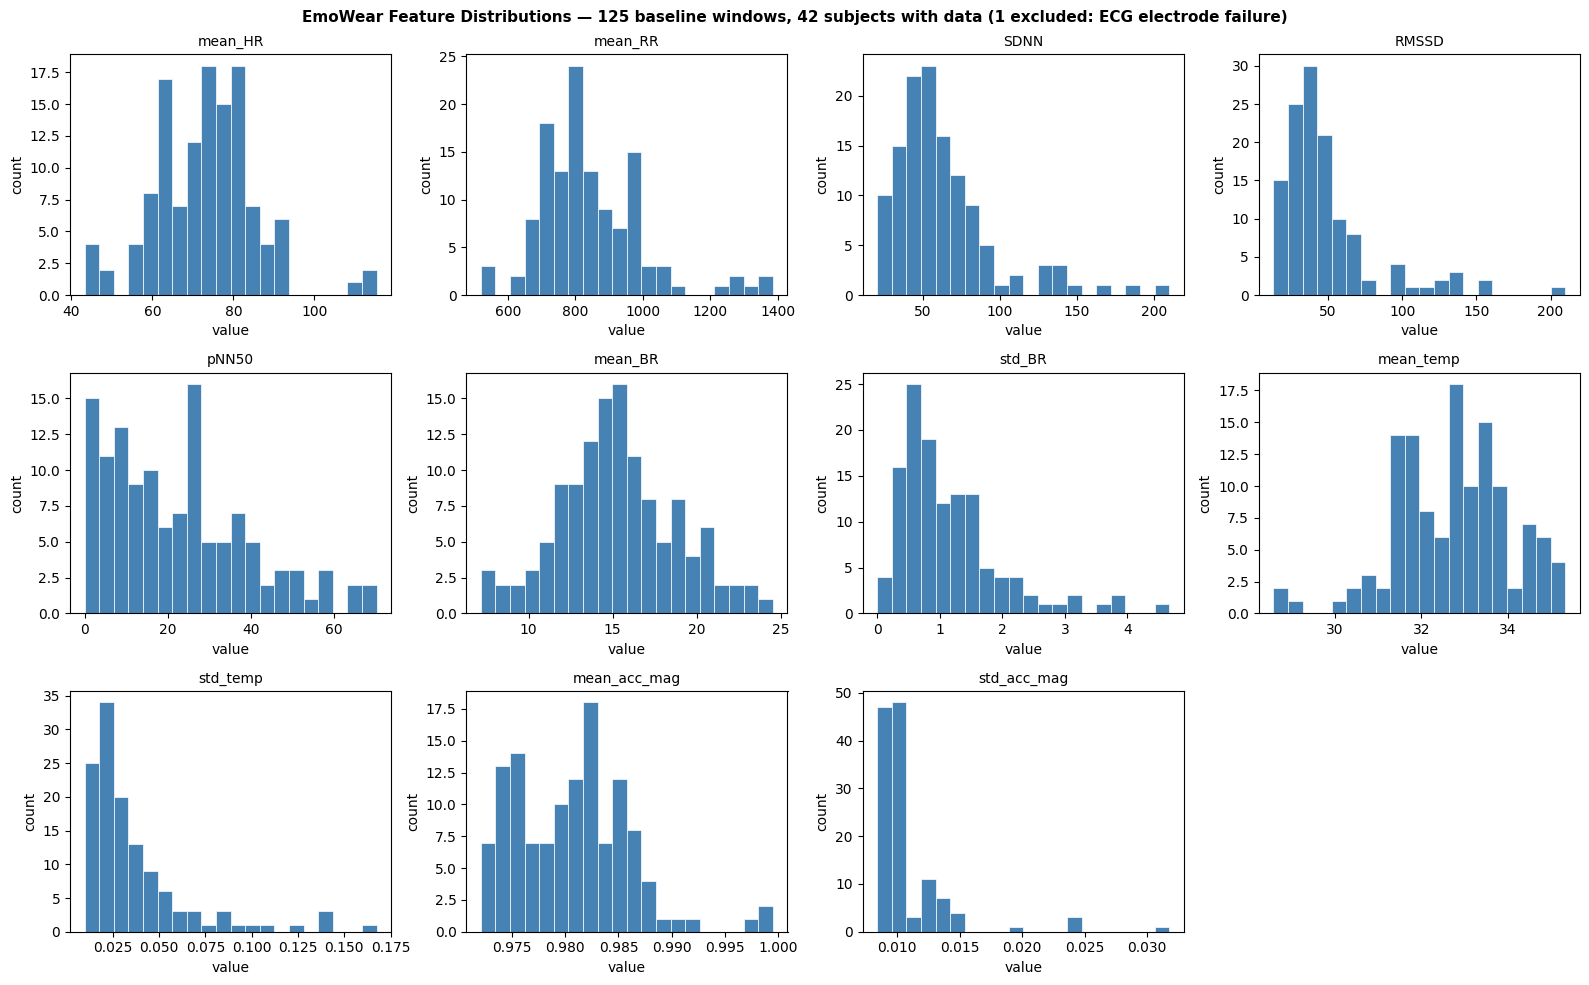

Distribution plot saved → /content/drive/MyDrive/R26_DS_012_RESEARCH_HDS/Outputs/EmoWear/reports/EmoWear_feature_distributions.png


In [7]:
# ═══════════════════════════════════════════════════════════════
# EmoWear — Cell 12: Verification — per-subject window counts
#                    and feature distribution sanity check
# ═══════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt

print("=== PER-SUBJECT WINDOW COUNTS ===")
print(f"{'Subject':<15} {'Windows':>8} {'Rejected':>9}")
print("-" * 35)
total_w     = 0
active_subj = 0
for sid in KEEP_FOLDERS:
    if sid in summary:
        nw = summary[sid]['n_windows']
        nr = summary[sid]['n_rejected']
        total_w += nw
        if nw > 0:
            active_subj += 1
        flag = '  <-- INVESTIGATE' if nw == 0 else ''
        print(f"{sid:<15} {nw:>8} {nr:>9}{flag}")
print(f"{'TOTAL':<15} {total_w:>8}")
print(f"\nSubjects with at least 1 window: {active_subj}")
print(f"Subjects with 0 windows (ECG failure): {len(KEEP_FOLDERS) - active_subj}")

print(f"\n=== FEATURE STATISTICS (raw, across all windows) ===")
print(f"{'Feature':<15} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
print("-" * 60)
for i, fname in enumerate(FEATURE_NAMES):
    col = X_all_raw[:, i]
    print(f"{fname:<15} {col.mean():>10.3f} {col.std():>10.3f} {col.min():>10.3f} {col.max():>10.3f}")

# ── Distribution plots ────────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, fname in enumerate(FEATURE_NAMES):
    axes[i].hist(X_all_raw[:, i], bins=20, color='steelblue', edgecolor='white', linewidth=0.5)
    axes[i].set_title(fname, fontsize=10)
    axes[i].set_xlabel('value')
    axes[i].set_ylabel('count')

axes[11].set_visible(False)

# Title now correctly says active_subj (42), not len(KEEP_FOLDERS) (43)
plt.suptitle(
    f'EmoWear Feature Distributions — {total_w} baseline windows, '
    f'{active_subj} subjects with data (1 excluded: ECG electrode failure)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plot_path = os.path.join(OUT_REPORTS, 'EmoWear_feature_distributions.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Distribution plot saved → {plot_path}')

In [9]:
!pip install reportlab -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 37.6 MB/s eta 0:00:00


In [10]:
# ═══════════════════════════════════════════════════════════════
# EmoWear — Cell 13: PDF preprocessing report
# ═══════════════════════════════════════════════════════════════

from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.lib.units import cm
from reportlab.platypus import (SimpleDocTemplate, Paragraph, Spacer,
                                 Table, TableStyle)
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle

pdf_path = os.path.join(OUT_REPORTS, 'EmoWear_preprocessing_report.pdf')
doc      = SimpleDocTemplate(pdf_path, pagesize=A4,
                              leftMargin=2*cm, rightMargin=2*cm,
                              topMargin=2*cm,  bottomMargin=2*cm)

styles = getSampleStyleSheet()
h1     = ParagraphStyle('h1',     parent=styles['Heading1'], fontSize=12, spaceAfter=6)
normal = ParagraphStyle('normal', parent=styles['Normal'],   fontSize=9,  spaceAfter=4)
small  = ParagraphStyle('small',  parent=styles['Normal'],   fontSize=8,  spaceAfter=2)

def P(text):
    return Paragraph(str(text), small)

def tbl_style():
    return TableStyle([
        ('BACKGROUND',    (0,0),  (-1,0),  colors.HexColor('#16213e')),
        ('TEXTCOLOR',     (0,0),  (-1,0),  colors.white),
        ('FONTNAME',      (0,0),  (-1,0),  'Helvetica-Bold'),
        ('ROWBACKGROUNDS',(0,1),  (-1,-1), [colors.white, colors.HexColor('#f0f4f8')]),
        ('GRID',          (0,0),  (-1,-1), 0.4, colors.HexColor('#cccccc')),
        ('LEFTPADDING',   (0,0),  (-1,-1), 4),
        ('RIGHTPADDING',  (0,0),  (-1,-1), 4),
        ('TOPPADDING',    (0,0),  (-1,-1), 4),
        ('BOTTOMPADDING', (0,0),  (-1,-1), 4),
        ('VALIGN',        (0,0),  (-1,-1), 'TOP'),
    ])

def tbl_style_with_total():
    s = tbl_style()
    s.add('BACKGROUND',    (0,-1), (-1,-1), colors.HexColor('#16213e'))
    s.add('TEXTCOLOR',     (0,-1), (-1,-1), colors.white)
    s.add('FONTNAME',      (0,-1), (-1,-1), 'Helvetica-Bold')
    return s

story = []

# ── Title ─────────────────────────────────────────────────────
story.append(Paragraph('EmoWear Preprocessing Report — R26-DS-012 Component 1', h1))
story.append(Paragraph('Dataset role: SSL baseline training only. No stress labels.', normal))
story.append(Spacer(1, 8))

# ── 1. Dataset overview ───────────────────────────────────────
story.append(Paragraph('1. Dataset Overview', h1))
story.append(Paragraph(
    'EmoWear: 49 questionnaire entries, 48 data folders (Code 35 has no folder). '
    'Devices: Zephyr BioHarness 3 chest (ECG 250Hz, BR 1Hz, ACC 100Hz, RR beat-by-beat firmware output) '
    'and Empatica E4 wrist (SKT 4Hz, BVP 64Hz, ACC 32Hz). '
    'File format: CSV, one folder per subject named XX-YYYY. '
    'Timestamps are relative seconds, already synchronized by dataset authors. '
    'params.csv correction NOT re-applied by this pipeline.',
    normal))
story.append(Spacer(1, 8))

# ── 2. Exclusions ─────────────────────────────────────────────
story.append(Paragraph('2. Subject Exclusions', h1))
excl_data = [
    [P('Code'), P('ID'), P('Reason')],
    [P('7'),  P('9UAD'), P('Daily antidepressant use. Antidepressants (SSRIs/SNRIs) directly alter autonomic tone and suppress HRV, corrupting the personalised baseline the LSTM-AE is trained on.')],
    [P('32'), P('9VZN'), P('Age 37, exceeds cutoff of 35.')],
    [P('34'), P('9W1R'), P('Age 38, exceeds cutoff of 35.')],
    [P('35'), P('9W29'), P('No data folder present. Age unknown.')],
    [P('46'), P('9WCE'), P('Age 39, exceeds cutoff of 35. Also on epilepsy medication (daily).')],
    [P('48'), P('9WDR'), P('Age 45, exceeds cutoff of 35.')],
    [P('39'), P('9W6G'), P('ECG electrode contact failure during entire baseline period. '
                           'bh3-rr.csv contains only 2 values per window, both equal to 32767 (0x7FFF), '
                           'the Zephyr firmware sentinel for no valid ECG contact. '
                           'BR, SKT, and ACC signals are clean but HRV cannot be recovered. '
                           'Subject kept in KEEP list but contributed 0 windows. '
                           'Excluded from combined arrays.')],
]
t1 = Table(excl_data, colWidths=[1.5*cm, 2*cm, 12.5*cm])
t1.setStyle(tbl_style())
story.append(t1)
story.append(Paragraph(
    'Age cutoff expanded to 35 (from 30 in original proposal) for cross-dataset consistency: '
    'PPG-DaLiA S1 (age 34) is already present in the combined SSL training pool. '
    'Subjects on non-psychoactive medications (antihistamines, NSAIDs, paracetamol, '
    'mesalazine, anticonception) were retained as none have documented HRV effects.',
    normal))
story.append(Spacer(1, 8))

# ── 3. Signals used ───────────────────────────────────────────
story.append(Paragraph('3. Signals and Sampling Rates', h1))
sig_data = [
    [P('Feature group'), P('Source file'), P('Rate'), P('Notes')],
    [P('mean_HR, mean_RR, SDNN, RMSSD, pNN50'),
     P('signals-bh3-rr.csv'),
     P('Irregular (beat-by-beat)'),
     P('Zephyr firmware RR intervals in ms. Only 2 of 6131 values outside 300-2000ms in S01. '
       'Firmware detection preferred over NeuroKit2 on 250Hz ECG.')],
    [P('mean_BR, std_BR'),
     P('signals-bh3-br.csv'),
     P('1 Hz'),
     P('Breathing rate in br/min. Warm-up artifact (BR=5) appears in first 3-40 samples for some subjects. '
       'Handled by 80% validity threshold.')],
    [P('mean_temp, std_temp'),
     P('signals-e4-skt.csv'),
     P('4 Hz'),
     P('Wrist skin temperature in degrees C. Range 25-40 filter applied.')],
    [P('mean_acc_mag, std_acc_mag'),
     P('signals-bh3-acc.csv'),
     P('100 Hz'),
     P('Chest ACC. Raw units are milligravity (mg), divided by 1000 to convert to grams (g). '
       'Mean magnitude across subjects is 0.974-0.990g, confirming correct units and resting posture.')],
]
t2 = Table(sig_data, colWidths=[4*cm, 3.5*cm, 2*cm, 6.5*cm])
t2.setStyle(tbl_style())
story.append(t2)
story.append(Paragraph(
    'Signals NOT used: bh3-ecg (raw), bh3-hr (derived HR), bh3-bb (breath-by-breath intervals), '
    'e4-bvp, e4-ibi, e4-acc, and signals-back/front/water files present in folders 48 and 49.',
    normal))
story.append(Spacer(1, 8))

# ── 4. Baseline definition ────────────────────────────────────
story.append(Paragraph('4. Baseline Definition', h1))
story.append(Paragraph(
    'Baseline: baselineB to baselineE from markers-unique.csv. '
    'Duration: exactly 120.0 seconds for all subjects. '
    'Three 60-second windows per subject with 30-second step: '
    '[bB, bB+60], [bB+30, bB+90], [bB+60, bB+120]. '
    'Timestamps are used as-is (already synchronized). params.csv not re-applied.',
    normal))
story.append(Spacer(1, 8))

# ── 5. Per-subject window counts ──────────────────────────────
story.append(Paragraph('5. Per-Subject Window Counts', h1))
story.append(Paragraph(
    '02-9TZO: Window 0 rejected. BR=5 br/min for 41 of 60 samples (68.3% invalid). '
    'Zephyr firmware warm-up artifact. Windows 1 and 2 clean and kept. '
    '39-9W6G: All 3 windows rejected. ECG electrode contact failure — see exclusion note above.',
    normal))
story.append(Spacer(1, 4))

win_data = [[P('Subject'), P('Windows Kept'), P('Rejected'), P('Log notes')]]
total_w  = 0
for sid in KEEP_FOLDERS:
    if sid in summary:
        nw = summary[sid]['n_windows']
        nr = summary[sid]['n_rejected']
        total_w += nw
        notes = '; '.join(summary[sid]['log']) if summary[sid]['log'] else ''
        win_data.append([P(sid), P(str(nw)), P(str(nr)), P(notes)])
win_data.append([P('TOTAL'), P(str(total_w)), P(''), P('')])

t3 = Table(win_data, colWidths=[3.5*cm, 3*cm, 2.5*cm, 7*cm])
t3.setStyle(tbl_style_with_total())
story.append(t3)
story.append(Spacer(1, 8))

# ── 6. Features ───────────────────────────────────────────────
story.append(Paragraph('6. Features (11 per window)', h1))
units = {
    'mean_HR':'bpm','mean_RR':'ms','SDNN':'ms','RMSSD':'ms',
    'pNN50':'%','mean_BR':'br/min','std_BR':'br/min',
    'mean_temp':'C','std_temp':'C','mean_acc_mag':'g','std_acc_mag':'g'
}
sources = {
    'mean_HR'    :'BH3 RR firmware',
    'mean_RR'    :'BH3 RR firmware',
    'SDNN'       :'BH3 RR firmware',
    'RMSSD'      :'BH3 RR firmware',
    'pNN50'      :'BH3 RR firmware',
    'mean_BR'    :'BH3 BR 1Hz',
    'std_BR'     :'BH3 BR 1Hz',
    'mean_temp'  :'E4 SKT 4Hz',
    'std_temp'   :'E4 SKT 4Hz',
    'mean_acc_mag':'BH3 ACC 100Hz',
    'std_acc_mag' :'BH3 ACC 100Hz',
}

# Feature stats from processed array
feat_header = [P('#'), P('Feature'), P('Source'), P('Unit'),
               P('Mean'), P('Std'), P('Min'), P('Max')]
feat_data   = [feat_header]
for i, fn in enumerate(FEATURE_NAMES):
    col = X_all_raw[:, i]
    feat_data.append([
        P(str(i)), P(fn), P(sources[fn]), P(units[fn]),
        P(f'{col.mean():.3f}'), P(f'{col.std():.3f}'),
        P(f'{col.min():.3f}'), P(f'{col.max():.3f}'),
    ])
t4 = Table(feat_data, colWidths=[0.6*cm, 2.8*cm, 3*cm, 1.2*cm,
                                   2*cm, 2*cm, 2*cm, 2.4*cm])
t4.setStyle(tbl_style())
story.append(t4)
story.append(Spacer(1, 8))

# ── 7. Normalisation ──────────────────────────────────────────
story.append(Paragraph('7. Normalisation', h1))
story.append(Paragraph(
    'Per-subject Z-score from own baseline windows only. '
    'Mean and std computed from all kept windows for that subject. '
    'Raw arrays also saved separately. '
    'Matches the personalised SSL design: each subject is their own physiological reference.',
    normal))
story.append(Spacer(1, 8))

# ── 8. Saved files ────────────────────────────────────────────
story.append(Paragraph('8. Saved Files', h1))
files_data = [
    [P('File'), P('Description')],
    [P('per_subject/EMW_NN_features_raw.npy'),  P('Raw feature array per subject (n_windows x 11)')],
    [P('per_subject/EMW_NN_features_norm.npy'), P('Z-score normalised features per subject')],
    [P('per_subject/EMW_NN_labels.npy'),        P('Labels — all 0 (baseline). No stress labels in this dataset.')],
    [P('per_subject/EMW_NN_norm_mean.npy'),     P('Normalisation mean vector (11,) from baseline windows')],
    [P('per_subject/EMW_NN_norm_std.npy'),      P('Normalisation std vector (11,) from baseline windows')],
    [P('combined/EMW_X_all_raw.npy'),           P('All subjects combined raw features (125 x 11)')],
    [P('combined/EMW_y_all.npy'),               P('All labels (all 0, baseline only)')],
    [P('combined/EMW_subject_ids.npy'),         P('Subject folder name per window for LOSO splits')],
    [P('EmoWear_feature_names.json'),           P('Full pipeline metadata, exclusion decisions, filter parameters')],
]
t5 = Table(files_data, colWidths=[6*cm, 10*cm])
t5.setStyle(tbl_style())
story.append(t5)

doc.build(story)
print(f'PDF saved -> {pdf_path}')

PDF saved -> /content/drive/MyDrive/R26_DS_012_RESEARCH_HDS/Outputs/EmoWear/reports/EmoWear_preprocessing_report.pdf
